# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [2]:
import yfinance as yf

# Escribe aquí tu código para descargar los datos de tus 3 activos elegidos
activos = ["QCOM", "VLO", "AXP"]

precios = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios.head()

[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker             AXP        QCOM         VLO         AXP        QCOM   
Date                                                                     
2024-01-02  182.611862  132.436523  121.295227  183.028858  134.297039   
2024-01-03  180.682083  129.952698  124.154472  181.816678  131.170998   
2024-01-04  182.063568  128.602158  120.970329  183.454785  129.697692   
2024-01-05  183.931473  129.131027  119.754204  184.369263  130.396566   
2024-01-08  184.077423  131.303223  120.004860  184.194163  131.416549   

Price                          Low                                Open  \
Ticker             VLO         AXP        QCOM         VLO         AXP   
Date                                                                     
2024-01-02  122.464914  180.439653  131.067112  120.728947  180.846942   
2024-01-03  125.435554  179.974162  129.376599  121.165258  181.031176   
2024-01-04  125.992583  180.720998  127.440521  120.896061  180.964216   
2024-01-05  121.935778  181.460380  128.299944  118.890866  181.752246   
2024-01-08  120.134825  181.324189  129.046051  115.632433  183.114273   

Price                                Volume                    
Ticker            QCOM         VLO      AXP     QCOM      VLO  
Date                                                           
2024-01-02  134.287600  121.276657  2236600  8495800  2638200  
2024-01-03  131.170998  121.230233  2720500  8133300  3078000  
2024-01-04  127.912732  124.925013  2777500  6770300  2586500  
2024-01-05  128.592713  121.155973  2243300  6827300  2958000  
2024-01-08  129.376605  117.442675  3442100  7729400  2756500

In [48]:
import yfinance as yf

# Explicación del error corregido:
# 1. yf.Ticker toma un solo símbolo a la vez. Para múltiples activos se debe usar un ciclo.
# 2. Las claves del diccionario (.info) deben ser textos (strings) entre comillas como ['sector'].
# 3. 'industry' es la clave correcta para obtener la industria en minúsculas.

for ticker_simbolo in ["QCOM", "AXP", "VLO"]:
    ticker = yf.Ticker(ticker_simbolo)
    info = ticker.info
    print(f"--- {ticker_simbolo} ---")
    print("Sector:", info.get('sector'))
    print("Nombre:", info.get('shortName'))
    print("Industria:", info.get('industry'))
    print()

--- QCOM ---
Sector: Technology
Nombre: QUALCOMM Incorporated
Industria: Semiconductors

--- AXP ---
Sector: Financial Services
Nombre: American Express Company
Industria: Credit Services

--- VLO ---
Sector: Energy
Nombre: Valero Energy Corporation
Industria: Oil & Gas Refining & Marketing



## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

In [32]:
cierre = precios["Close"]

cierre.head()


Ticker,AXP,QCOM,VLO
Date,,,
2024-01-02,182.611862,132.436523,121.295227
2024-01-03,180.682083,129.952698,124.154472
2024-01-04,182.063568,128.602158,120.970329
2024-01-05,183.931473,129.131027,119.754204
2024-01-08,184.077423,131.303223,120.004860


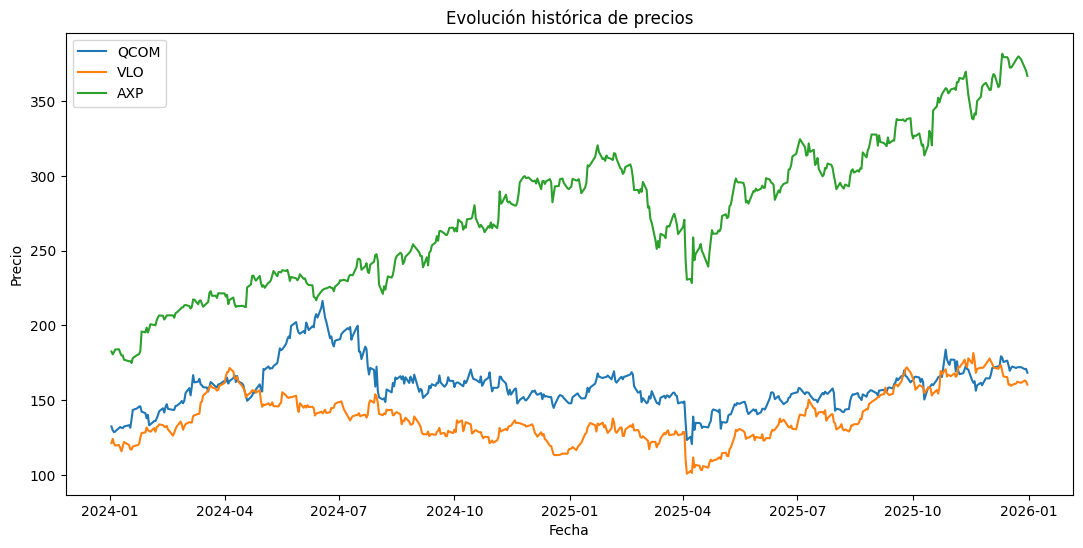

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(cierre.index, cierre[activo], label=activo)

ax.set_title("Evolución histórica de precios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()

plt.show()

In [35]:
cierre_normalizado = cierre / cierre.iloc[0] * 100
cierre_normalizado.head()

Ticker,AXP,QCOM,VLO
Date,,,
2024-01-02,100.000000,100.000000,100.000000
2024-01-03,98.943235,98.124516,102.357261
2024-01-04,99.699749,97.104752,99.732143
2024-01-05,100.722631,97.504090,98.729527
2024-01-08,100.802555,99.144269,98.936177


## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

In [10]:

rendimiento = cierre.pct_change()
rendimiento.head()


Ticker,AXP,QCOM,VLO
Date,,,
2024-01-02,NaN,NaN,NaN
2024-01-03,-0.010568,-0.018755,0.023573
2024-01-04,0.007646,-0.010393,-0.025647
2024-01-05,0.010260,0.004112,-0.010053
2024-01-08,0.000794,0.016822,0.002093


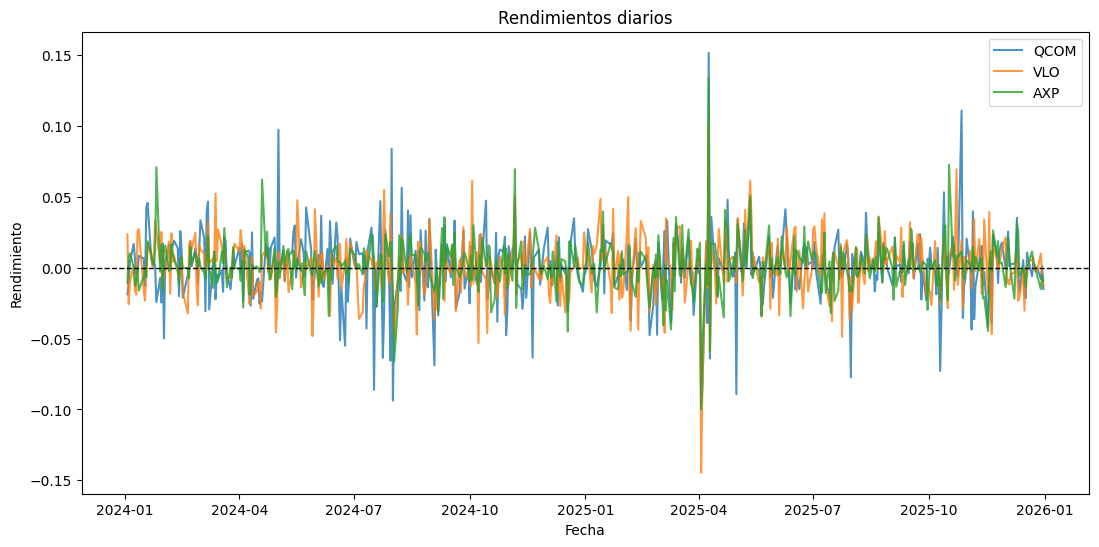

In [27]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        rendimiento.index,
        rendimiento[activo],
        label=activo,
        alpha=0.8
    )

ax.axhline(0, linewidth=1, color="black", linestyle="--")
ax.set_title("Rendimientos diarios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento")
ax.legend()

plt.show()

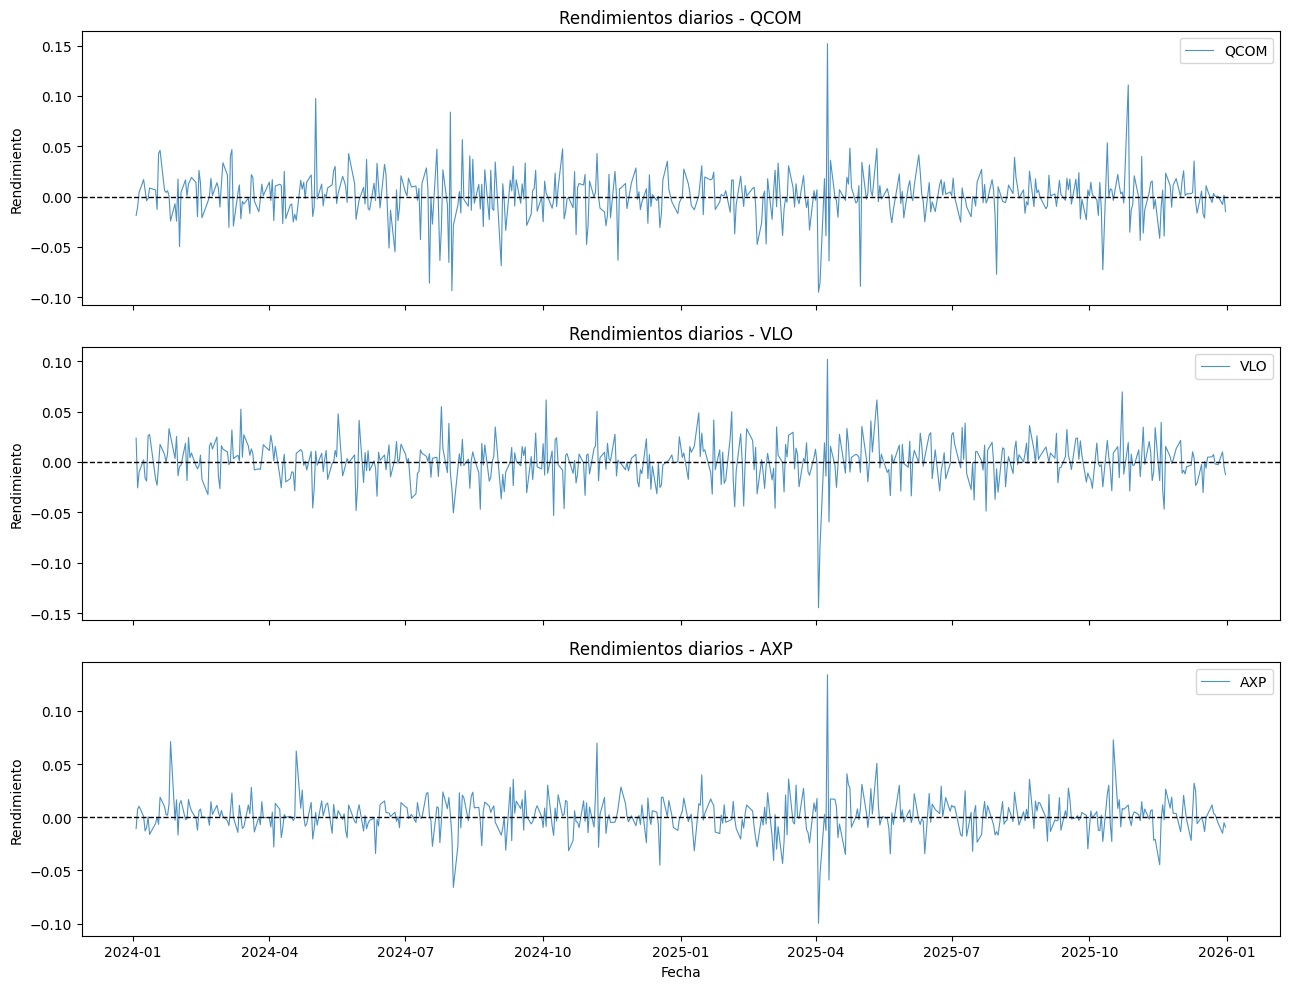

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for ax, activo in zip(axes, activos):
    ax.plot(
        rendimiento.index,
        rendimiento[activo],
        label=activo,
        linewidth=0.8,
        alpha=0.8
    )

    ax.axhline(0, linewidth=1, color='black', linestyle='--')
    ax.set_title(f"Rendimientos diarios - {activo}")
    ax.set_ylabel("Rendimiento")
    ax.legend()

axes[-1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

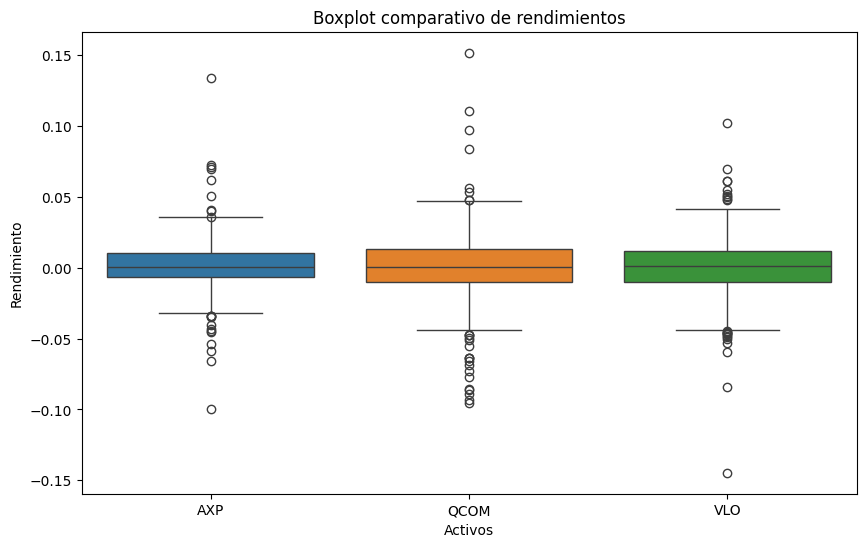

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(data=rendimiento)

plt.title("Boxplot comparativo de rendimientos")
plt.xlabel("Activos")
plt.ylabel("Rendimiento")

plt.show()

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

Matriz de correlación de Pearson:


Ticker,AXP,QCOM,VLO
Ticker,,,
AXP,1.000000,0.452938,0.409660
QCOM,0.452938,1.000000,0.337845
VLO,0.409660,0.337845,1.000000


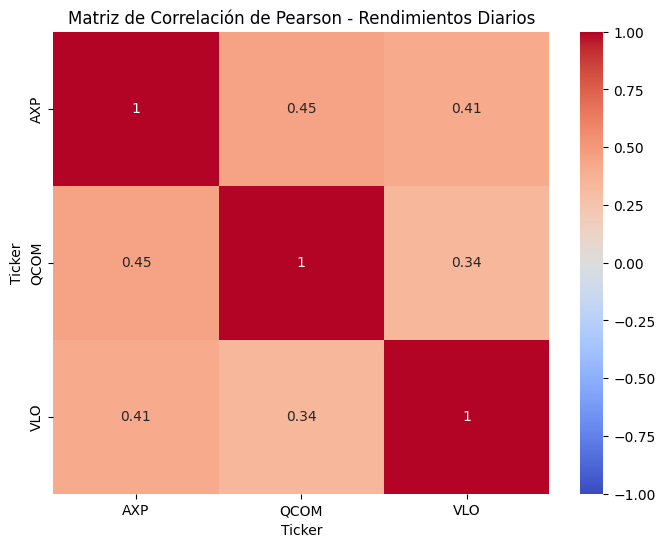

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular la matriz de correlación de Pearson usando la variable correcta 'rendimiento'
matriz_correlacion = rendimiento.corr()

print("Matriz de correlación de Pearson:")
display(matriz_correlacion)

# 2. Crear y mostrar el Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Matriz de Correlación de Pearson - Rendimientos Diarios")
plt.show()

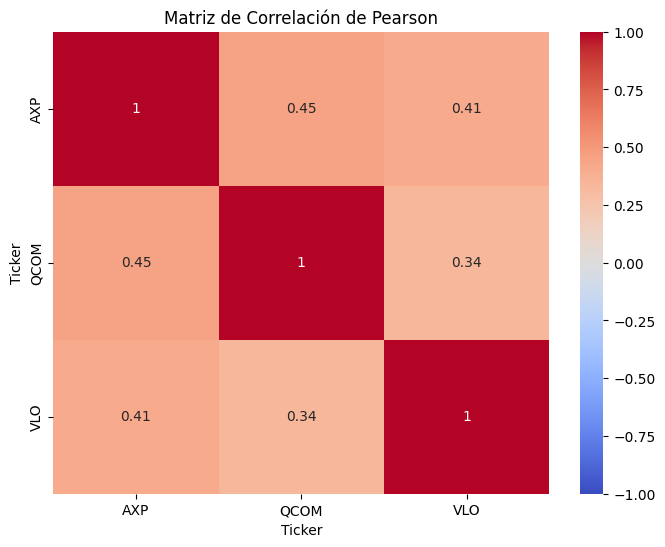

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear y mostrar el Heatmap usando la variable 'matriz_correlacion' ya calculada
plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Matriz de Correlación de Pearson")
plt.show()

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [51]:
import pandas as pd


resumen = pd.DataFrame({
    'Media': rendimiento.mean(),
    'Mediana': rendimiento.median(),
    'Desviación Estándar': rendimiento.std(),
    'Mínimo': rendimiento.min(),
    'Máximo': rendimiento.max()
}).T

resumen

Ticker,AXP,QCOM,VLO
Media,0.001549,0.000770,0.000782
Mediana,0.000893,0.000879,0.001262
Desviación Estándar,0.017654,0.024101,0.021073
Mínimo,-0.099655,-0.095145,-0.144664
Máximo,0.133843,0.151853,0.101921


Conclusión para el inversionista
En conclusión, el análisis de los rendimientos diarios de QCOM, VLO y AXP muestra que las tres acciones presentan rendimientos generalmente cercanos a cero, aunque con episodios de mayor volatilidad. Esto indica que, durante el período analizado, los movimientos diarios fueron relativamente impredecibles y estuvieron acompañados de fluctuaciones puntuales importantes. Para un inversionista ficticio, QCOM, VLO y AXP podrían representar oportunidades de diversificación, pero sus niveles de riesgo y volatilidad deben considerarse antes de tomar una decisión. En particular, no sería recomendable evaluar una inversión únicamente por el rendimiento promedio; es necesario complementar este análisis con la desviación estándar, el rendimiento acumulado y otras medidas de riesgo para determinar cuál ofrece la mejor relación entre rentabilidad y riesgo.

